# Matplotlib - Format Charts
___
- EG: `fig, ax = plt.subplots()`
- We have Analyzed the Top Skills for Data Scientist, Engineer and Analyst but now, it's time to Compare the Values across all these Jobs!
- Problem is, they are all on separate Plots... so how do we do this?
    - Well convieniently, the `pyplot` Module from Matplotlib offers a `subplots()` Function
        - This lets us Graph everything on **one single figure**
- Best way to understand this, is to go to the [Cheetsheet](https://matplotlib.org/cheatsheets/)
    - Looking at the section called **Subplots Layout** there's a Function called `plt.subplots()`
        - With this Function, we can specify, the Rows and Columns for the Number of Axes on the Figure itself.
        - Running this Function specifying a 3 x 3. Returned are 2 Objects, a **tuple**, a `fig` and an `axs`
        - **Note**: An `axs` Object is each of the individual Plots (squares on the Diagram) on this `fig`

In [14]:
# Imports
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)

- For our first attempt, we are going to Create a Subplot on a 1x1 Figure
    - It provides 2 Objects
        - `fig`
        - `ax`
    - The standard nomanclature for this is: `fig, ax = `
    - **Note**: This can be named anything as desired... but it's very common to use `fig` and `ax`
    - Then Calling out the `plt` Module, specifically the `.subplots()` Function
    - Running it to make sure it works and to make sure the correct Method was Invoked

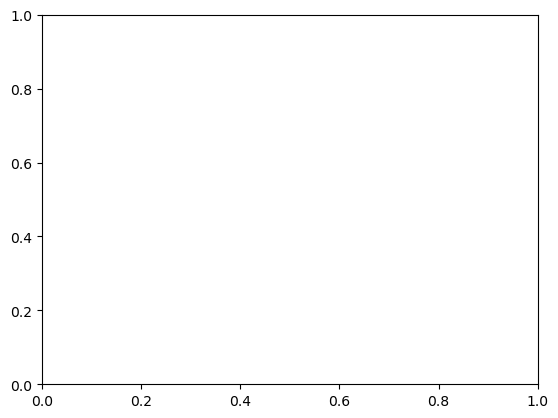

In [3]:
# Creating a simple Subplot on a 1x1 Figure using .subplot() Function
fig, ax = plt.subplots()

- As we can see from above, a basic Graph has been Plotted
- Adding in the Arguments for the **rows** and **columns** into the `.subplots()` Function, will Yield a Subplot Area with the specified Values
    - EG: Providing 2 for both the Rows and Columns will give a 2x2 Subplot Area

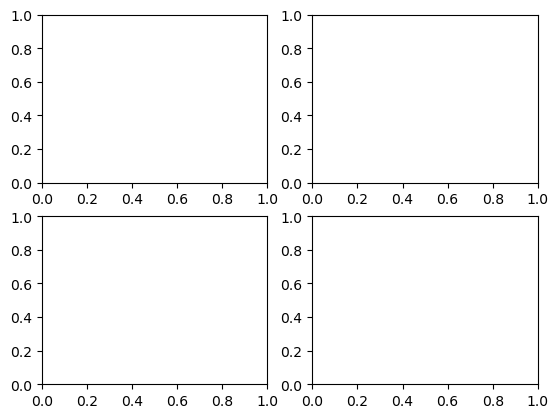

In [4]:
# Making a 2x2 Subplot Area
fig, ax = plt.subplots(2, 2)

- Keeping it simple for now, we will just work off of a 1x1 so we get to grips with how `subplots()` work
- Let's Plot, the **Counts** of the `job_title_short` Column
    - As always, using `.value_counts()` on the `df[job_title_short]` Column to get the Counts
    - Then using the `.plot()` Method alongside this, Plotting the Results on a bar chart, using `kind='bar'`
- Running this, we have what we want

<Axes: xlabel='job_title_short'>

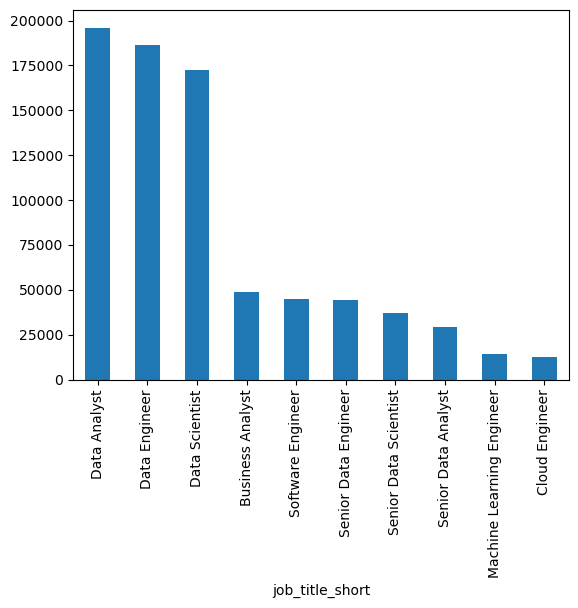

In [5]:
# Plotting the Counts of the job_title_short Column in a bar chart
df['job_title_short'].value_counts().plot(kind='bar')

- Using the Plot that above, it's time to start using the `ax`
- To do this, we can Pass in the `ax` inside the `.plot()` Method, alongside the `kind`
    - This is the **Axis** for the **Figure** itself
- To do this, all that's needed is like so: `.plot(kind='bar', ax=ax)`
    - Specify `ax=` and then make it Equal to `ax`(This one was the one specified alongside the `fig` when making the Subplot)
    - Adding that in and Running it, will not change anything, it's still going to be the same Count Values of the different Job Titles

<Axes: xlabel='job_title_short'>

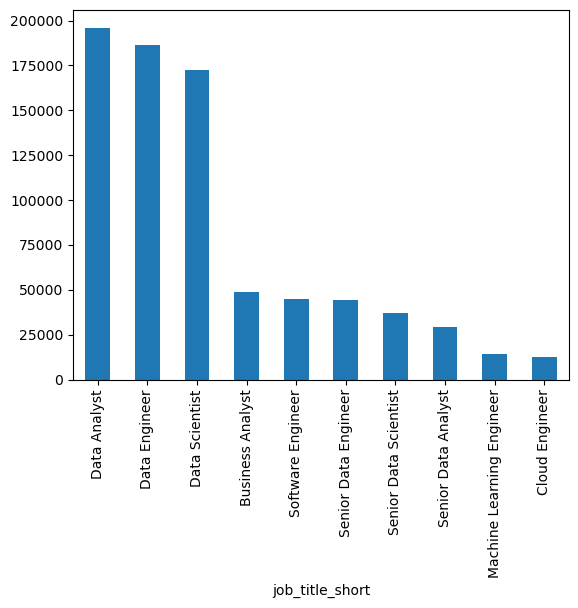

In [6]:
# Using the ax variable we specified in the Subplot, and making it equal the Plot with the Job Title Counts

# Creating the Basic Subplot again
fig, ax = plt.subplots()

# Making the Bar Chart for the Counts of job_title_shorts but including the ax Variable
df['job_title_short'].value_counts().plot(kind='bar', ax=ax)

- Now it's time to start Plotting 2 Plots!
- For that we will ofc, need a Second Plot
    - For the first one, it will be the Value Counts of the different `job_title_short` (The one made above)
    - The second one will be, a Value Count on the `job_schedule_type` but only looking at the first 3 Values
- Then we will need to get both of these Plots, into separate Bar Charts and then Add them on the same Figure (`fig`)
- Let's Set up the Data and get what we need so we can start Plotting them
    - To get the Data for the First Plot:
        - Do a `.value_counts()` on the `job_title_short`
    - To get the Data for the Second Plot:
        - Do a `.value_counts()` on the `job_schedule_type`
        - To get the Top 3, using `.head(3)` 

In [7]:
# Getting the value_counts for job_title_short
df['job_title_short'].value_counts()

job_title_short
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Business Analyst              49063
Software Engineer             44929
Senior Data Engineer          44563
Senior Data Scientist         36957
Senior Data Analyst           29216
Machine Learning Engineer     14080
Cloud Engineer                12331
Name: count, dtype: int64

In [8]:
# Getting the value_counts for job_schedule_type and only Returning the Top 3 back
df['job_schedule_type'].value_counts().head(3)

job_schedule_type
Full-time     701727
Contractor     34793
Internship      8742
Name: count, dtype: int64

- Now, to Plot these, make them into Seperate Bar Charts and put them on the same Figure (`fig`)
    - Starting off specifying `fig` and `ax`
    - Making them equal to, `plt.subplots()`
    - Here, we pass in a Numerical Value for the **rows** (How many Lines of Graphs we want on the Figure)
        - In this case, it's 1 (since we only has 2 Graphs to Compare and want them side by side, not on top of each other)
    - Then, we pass in a Numerical Value for the **columns** (How many Graphs we want side by side on the Figure)
        - In this case, it's 2 (since we want to Compare 2 Graphs against each other)
    - Then, we Grab what we Created above and Paste it below the `.subplots()` Line (Grab the Code for Counts of `job_titles` and Counts of the Top 3 `job_schedule_type`)
        - Then Plotting both on separate Bar Charts, using `.plot(kind='bar')`
        - Don't forget to pass in the `ax=` inside the Plot Method on both as well, and Set it Equal to `ax`

AttributeError: 'numpy.ndarray' object has no attribute 'get_figure'

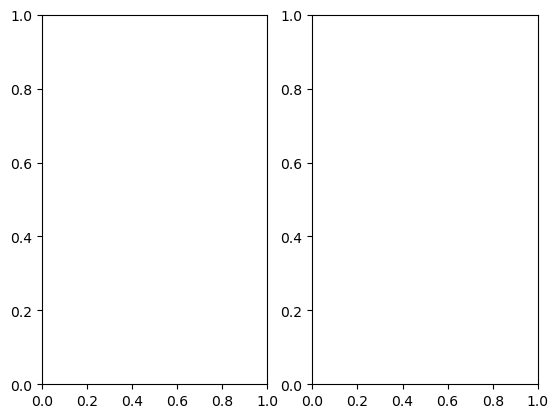

In [9]:
# Creating our Subplot with 1 Row and 2 Columns
fig, ax = plt.subplots(1, 2)

# Plotting our value_counts Data in separate Bar Charts for both the job_counts and job_schedule_type and specifying the ax Values as well
df['job_title_short'].value_counts().plot(kind='bar', ax=ax)
df['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax=ax)

- Passing both of the `ax` Values here equals to the same Value will produce an Error
- Running the above, an Error occurrs as expected
    - Reason is: We need to Specify the **Index** of the `ax` that is being used
    - This is similar to a List, when Passing in an **Index**, square bracket notation is used `[]`
    - Following the sequence for **Indexes**, we start at 0 and end at 9.
        - First Plot will be Index[0] - `ax=ax[0]`
        - Second Plot will be Index[1] - `ax=ax[1]`

Text(0, 0.5, '')

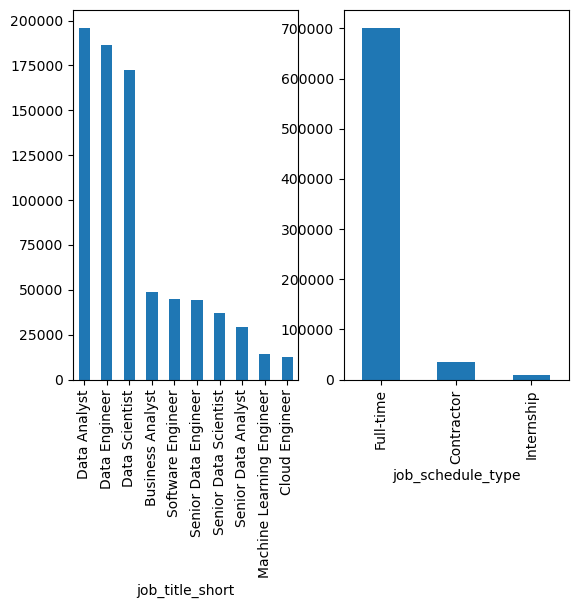

In [ ]:
# Setting the Indexes for the Individual Plots to place them on the subplots
fig, ax = plt.subplots(1, 2)

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[0])
df['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax=ax[1])

- We get back the 2 Bar Charts, side by side on the same Figure so we can compare them
    - Count of the `job_title_short` on the Left
    - Count of the `job_schedule_type` on the Right
- To switch them around, all that's needed is to trade/swap the Indexes
    - If you want to have the `job_schedule_type` on the Left and the `job_title_short` on the Right:
        - Specify `ax=ax[1]` for `job_title_short`
        - Specify `ax=ax[0]` for `job_schedule_type`
- As seen above, there is Overlap appearing between the two Visualizations with the X Axis Values, spilling into the Chart on the Left...
    - This can be Fixed, by passing in a Function called: `.tight_layout()`
    - This Function needs to be Applied to the entire Figure
    - Above, we have `fig` and `ax`
        - `fig`: This is the entire thing
        - `ax`: This is the Individual Plots
    - Since we have already utilized `ax`, it's time now to utilize `fig`
        - Specify `fig`
        - Then add in `.tight_layout()`
    - That's all that's needed, Running with this, will make it look all nice and neat and tidy!

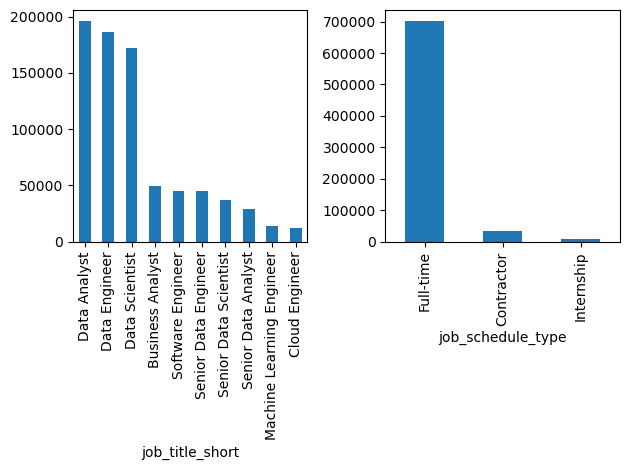

In [11]:
# Running all the above Code but adding in tight_layout() to make everything lok nice
fig, ax = plt.subplots(1, 2)

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[0])
df['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax=ax[1])

fig.tight_layout()

- Now we get back something that's a lot more readable where they are separated nicely and the information is not overlapping
- We are currently using the Pandas Methods to Plot these different Visualizations
- Below, is the same Visualizations but using Matplotlib's Designed way of building Visualizations

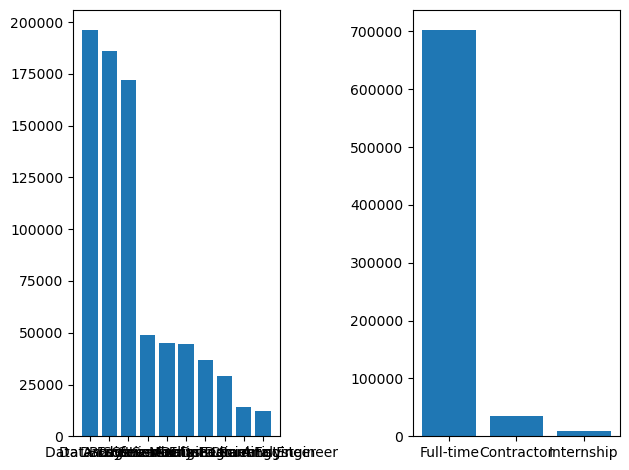

In [17]:
# Using Matplotlib's way of building the same Visualizations
fig, ax = plt.subplots(1, 2)

ax[0].bar(df['job_title_short'].value_counts().index,df['job_title_short'].value_counts())
ax[1].bar(df['job_schedule_type'].value_counts().head(3).index, df['job_schedule_type'].value_counts().head(3))

plt.tight_layout()

- Running this produces the same thing... kind of...
    - The Labels aren't turned on their side so there is overlap happening there but it's pretty much the same thing
- So what is the Code actually doing?
    - First, calling out the different Axis
    - Then Running the applicable Plot Method on it
    - Providing the Values that we want to Display in this Plot
    - And Filtering it out
    - Then adding in the tight_layout to make it look all presentable
- But, this way of doing it is more verbose and there's a lot of repeating Code... compared to the Pandas way of doing it
- The nicer way of doing it, is utilizing the Pandas Methods to Plot this information

- Now it's time to Focus on the Final Example that was Discussed at the beginning of the Lesson
    - We want to Plot all the different Counts of `top_skills` for Data Scientist, Engineer and Analyst on **1 single Plot**
    - To do this, we are going to use that same DataFrame that was Created during the Explodes Lesson
        - Copied the DataFrame into Skills
        - Exploded all the Skills out
        - Grouped them, reset the Index
        - Then Sorted the Values by the different Skill Counts

In [43]:
# Re-Creating the DataFrame from the Explodes Lesson
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count = df_skills_count.sort_values(by='skill_count', ascending=False)

df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


- Because we want to Plot Data Analyst, Engineer and Scientist the first thing that needs to be done is to...
    - Create a List, with all those Job Titles in there
    - Using a List, because we are going to Loop through each of these different `job_titles` to basically pull them out of the above and then Plot them individually onto our Figure
    - Then Create the `fig` and `ax` as we have done previously
    - Specify the `.subplots()` Function
    - Now Specify the `rows` and `columns` Values: Because this time, we are stacking it, we will need **3 rows and 1 column**
    - Time to loop through each Record in the DataFrame using a `for` loop
    - Specifying the Iterators as `i` and also the `job_title`
    - Using the `in` Keyword alongside the `enumerate()` Keyword and passing in `job_titles` (The List of Jobs that we stored in our Variable)
        - As a refresher, whenever we `enumerate()` through a List, it Provides first the **Index**, then it Provides the actual **Value**
        - So, the `i` Variable stores the **Index** of the Job Titles and the `job_title` Variable, stores the actual name itself of the Job Title as the **Value**
        - Printing it out would yield: 0 Data Scientist, 1 Data Engineer, 2 Data Analyst
    - Then to define the `for` loop, adding in the colon at the end `:`
    - First thing to do inside the Loop is to:
        - Filter the DataFrame `df_skills_count` just for the Values inside of our List Variable of `job_titles`
            - In this Case, we have Data Scientist first, we want to Filter it just for Data Scientist and for the Top 5 Skills for that Job
        - To do this, specify the DataFrame of `df_skills_count[]`, Filter it down by Job Title `df_skills_count['job_title_short']`
        - Using the Compare Operator `==`
        - Looking for what's stored in the Iterator Variable of `job_title`
        - And because we only want the Top 5 Skills, using `.head()`
    - To Verify if we are getting the correct Results, we can wrap it in a `print()` to make sure we are on the right track
    - Because we are getting what we want and actually going in the right direction, we are going to Set this to a DataFrame Variable of `df_plot =`
    - Now it's time to Plot everything by Running the `.plot()` Method on the `df_plot` Variable
        - Start by having `df_plot.plot()`
        - Specify the Chart we want with `kind='barh'`. Because we are using a Horizontal Bar Chart, need to Specify the X and Y Axis. To do this we Set:
            - `x='job_skills'`
            - `y='skill_count'`
        - Now we need to Provide the Axis, on what Axis we want to Plot these Visualizations on...
            - Because we did the `enumerate()` Function which provides the **Index** with the `i` Variable, we can Access the different Indexes as they are Iterated through!
        - We can Pass into our `ax` the Variable `i` as this will give it the correct Index as it iterates through due to it being stored inside of `i`
        - The notation is as always: `ax=ax` and then adding in the Square Bracket Notation and Passing in the `i` Variable like so: `[i]`
- With that we get back the Top 5 Skills for each of the 3 specified Job Titles, Plotted on Horizontal Bar Charts, Stacked on top of each other on a Subplot, on 1 Figure 

- So we got what we want! But it's a bit messy as there's no Titles, there's overlap and we have no idea what Graph is for what `job_title`...
- Now it's time to do some Cleanup
    - To show all the different `job_titles` above each Graph
    - Pass in the Parameter `title=` inside the `.plot()` Method and Set it Equal to `job_title` which is the Iterator Variable in the `for` Loop, that stores the Individual Title from the List specified at the start
    - Next, we want to Display our `job_skills` on the Graphs in Descending Order, we want to Sort them and make it flow nice
        - Similar to last Lesson where we Inverted the Y Axis, we are going to do the same thing here
        - Last time we needed to use the `gca()` Method to Access and Access and that's how we were able to do it. This time, we won't have to do that
        - This time, we call out the Axis specifically by using ax and Specifying the **Index** by using `ax[i]`
        - Then invoking the `.invert_yaxis()` Method
        - This Inverted all those different Values
    - Now time to take out the `job_skills` on the Y Label as it's not really needed and it's redundant
        - Again, we want to Access the Axis and Access each individual **Index** so we will need to use `ax[i]`
        - Then invoke `.set_ylabel('')` Method and Set it to a Blank String with the empty Quotes `''`
    - Now, let's get rid of the Legend, because again it's redundant and doesn't add anything
        - Again, we want to Access the Axis and Access each individual **Index** so we will need to use `ax[i]`
        - Then invoke `.legend()` Method, afterwards, invoke the `.set_visible()` Method and Passing in the Boolean Value of `False` to make it disappear
    - Now, let's set the X Limit for all Graphs and make them consistent and Comparable, because the Data Analyst Graph is only going to 80_000 and it's not consistent
        - Again, we want to Access the Axis and Access each individual **Index** so we will need to use `ax[i]`
        - Then invoke `.set_xlim()` Method, Passing in the Starting and Ending Values for the X Axis of the Graph
            - We want the Axis to Start at 0
            - We want the Axis to End at 120_000 because that is the relative to the longest Line across all 3 Visualizations and we want them all to have the same Axis Length
    - Now to Set a Title for all of this, we want to do this on the Figure
        - We don't want to give a Title to each Individual Visual as that doesn't make sense, we want to Put the Title on the Figure as it explains what all 3 Graphs are for and is the main Title
        - Specify `fig`
        - Invoke the `.suptitle()` Method, Passing in the String that we want as the Title on the Figure, alongside Passing in the fontsize using `fontsize=` and assigning it a Value
    - Now, we want to Address the Overlap happning for all the Visuals on the Figure
    - It's best to Addess this one time and make it tight on the Figure, rather then Adding it to the Loop and making each Visual Tight after it gets Created
    - It makes more sense, to Address this on the Figure overall after all Visuals are Created
        - Again, Specify `fig`
        - Invoke the `.tight_layout()` Method, that we learned about earlier and this will address the overlap and make everything neat and tidy and Presentable

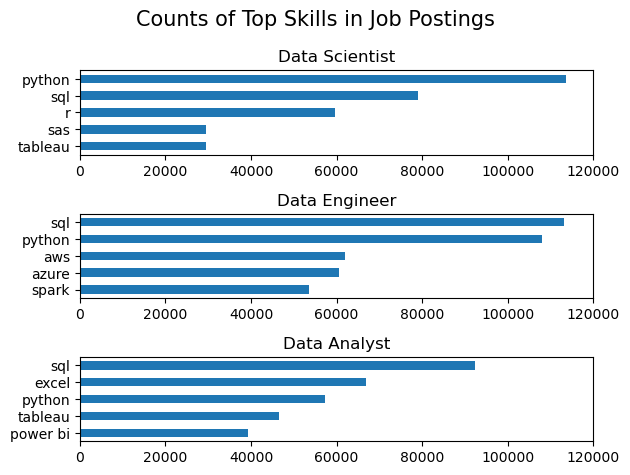

In [78]:
# Plotting all the different Counts of `top_skills` for Data Scientist, Engineer and Analyst on a single Plot
job_titles = ['Data Scientist', 'Data Engineer', 'Data Analyst']

fig, ax = plt.subplots(3, 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head()
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 120_000)

fig.suptitle('Counts of Top Skills in Job Postings', fontsize=15)
fig.tight_layout()

### Closing Remarks and Insights Learned
___
- Data Scientist and Data Engineer's have some of the Highest Counts with Python
    - With Data Analyst a good bit below that
- But when it comes to SQL, it tops the Charts for Data Engineer's and Data Analysts
    - While it still remains really high for Data Scientist, it's still less coveted compared to the other jobs